# Metric Learning

**Metric Learning (обучение метрике)** — это метод машинного обучения, направленный на автоматическое создание метрик расстояния между точками данных, специально адаптированных под конкретную задачу.

Основная идея заключается в том, что вместо использования стандартных метрик расстояния (например, евклидова, косинусного или манхэттенского расстояния), алгоритм учится определять наиболее подходящую метрику на основе обучающих данных.

Важно: Metric Learning может использоваться как при обучении с учителем (supervised learning), так и без него (unsupervised learning).

К основным постановкам задач Metric Learning относят задачи **кластеризации**, задачи **поиска ближайших соседей**, задачи **снижения размерности** и **частичного восстановления данных**.

<img src='Images/ml_13.png'>

Самое простое преобразование пространства, известное ещё со школы — это поворот вокруг одной из осей в трехмерном пространстве на угол alpha.

**Поворот в трехмерном пространстве** — это базовое преобразование, при котором все точки объекта вращаются вокруг выбранной оси на заданный угол.

Основные понятия:

* Угол поворота (alpha) — величина, на которую происходит вращение.
* Ось вращения — фиксированная прямая линия, вокруг которой происходит поворот.

Матрица поворота вокруг оси X

$$
M_x(\alpha) = 
\begin{pmatrix}
1 & 0 & 0 \\
0 & \cos\alpha & -\sin\alpha \\
0 & \sin\alpha & \cos\alpha
\end{pmatrix}
$$

Матрица поворота вокруг оси Y

$$
M_y(\alpha) = 
\begin{pmatrix}
\cos\alpha & 0 & \sin\alpha \\
0 & 1 & 0 \\
-\sin\alpha & 0 & \cos\alpha
\end{pmatrix}
$$

Матрица поворота вокруг оси Z

$$
M_z(\alpha) = 
\begin{pmatrix}
\cos\alpha & -\sin\alpha & 0 \\
\sin\alpha & \cos\alpha & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

# Метод ближайших соседей. Кластеризация


Основная сложность задачи кластеризации заключается в том, что не всегда известно истинное значение количества кластеров — иногда надо это исследовать.

---

Задача поиска ближайших соседей (k Nearest Neighbours, kNN) очень схожа с задачей кластеризации. Основное отличие заключается в том, что кластеризация — задача разбиения на кластеры, с последующим описанием и интерпретацией общих черт кластера. В свою очередь, поиск ближайших соседей состоит в определении уже существующего кластера, к которому относится объект.

Другими словами, поиск ближайших соседей используется для задачи обучения с учителем, где целевые метки предварительно могут быть получены, например, кластеризацией. 

Задачи обучения с учителем, где целевые метки получены в результате кластеризации, называются слабым обучением с учителем (weak supervised learning).

### Алгоритм работы k-nearest neighbour (KNN)

* Зададим k — количество ближайший соседей, по которым принимается решение.
* Выберем расстояние, по которому будут определяться соседи. Обычно это евклидово расстояние.
* Обучим модель на признаковом пространстве.

Как было сказано ранее, обучение алгоритма kNN заключается в получении пар признаковое пространство-целевая метка. Далее данные нормализуются с использованием MinMaxScaler(). Напомним его формулу:

$X = \frac{X - min[X]}{max[X] - min[X]}$

* Получим предсказание модели.

Предсказание заключается в поиске k ближайших соседей на основе метрики, выбранной ранее. Данная модель в sklearn реализована в модуле sklearn.neighbors как **KNeighborsClassifier** для задачи классификации и **KNeighborsRegressor** для задачи регресии.

**KNeighborsClassifier**. Давайте подробнее разберём все параметры модели:

* n_neighbors — количество соседей, по умолчанию 5.
* weights{'uniform', 'distance'} — вес объекта в зависимости от удаленности от объекта. Как говорилось ранее, если uniform, то расстояние не будет учитываться в подсчёте вероятности для классификации. По умолчанию оно не учитывается, параметр имеет значение 'uniform'. При 'distance' расстояние учитывается!

* algorithm — алгоритм, используемый при подсчёте расстояния.
1. 'ball_tree' использует BallTree.
2. 'kd_tree' использует KDTree.
3. 'brute' использует жадный алгоритм.
4. 'auto' выбирает оптимальный из вышепредставленных.

* leaf_size — параметр для поиска расстояния BallTree или KDTree. По умолчанию равен 30.
* p — значение p-метрики Миньковского. Как мы знаем, p=1 — расстояние Манхэттена (L1), p=2 — Евклидово расстояние (L2). По умолчанию p=2.
* metric — метрика для оценки расстояний, по умолчанию расстояние Миньковского.
* n_jobs — количество задач, выполняемых параллельно, ограничено количеством ядер вычислительной машины. При n_jobs=-1 использует все.

### Приведём пример:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')
from sklearn.neighbors import KNeighborsClassifier

Сформируем искусственные данные:

In [4]:
data = pd.DataFrame([
    [0,0,0],
    [0.2,0.1,0], 
    [1,0,0], 
    [2,1,1],
    [2.5,0.9,1], 
    [3,1,1]], 
    columns = ['x','y', 'target'])
data.head()

,x,y,target
0,0.0,0.0,0
1,0.2,0.1,0
2,1.0,0.0,0
3,2.0,1.0,1
4,2.5,0.9,1


Отделим матрицу признаков и вектор-столбец правильных ответов:

In [10]:
X = data.drop(['target'], axis=1)
y = data['target']

Обучим kNN с тремя соседями:

In [11]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Посмотрим на визуализацию исходных данных и работы модели по классификации точки. Вероятность принадлежности к классу можно вычислить методом **predict_proba()**, а само предсказание — методом **predict**:

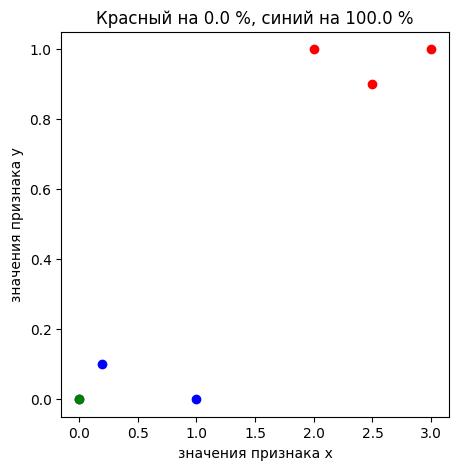

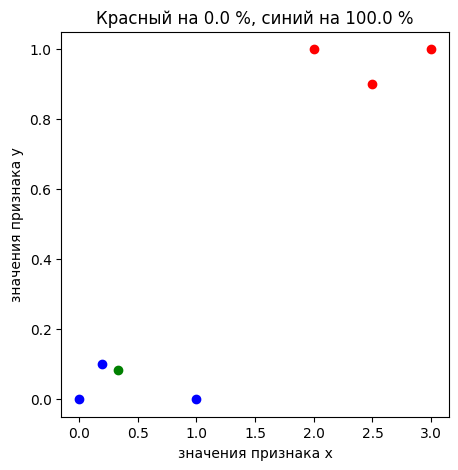

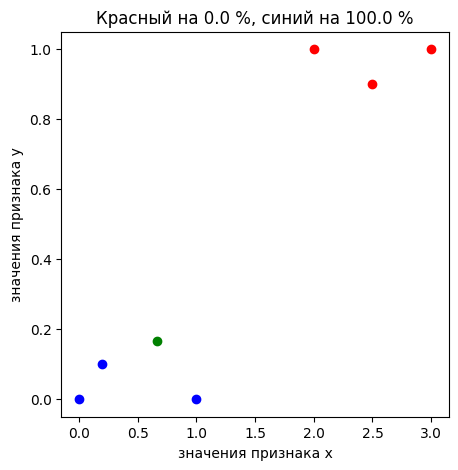

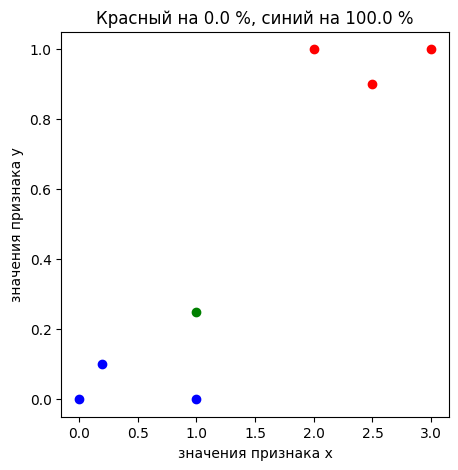

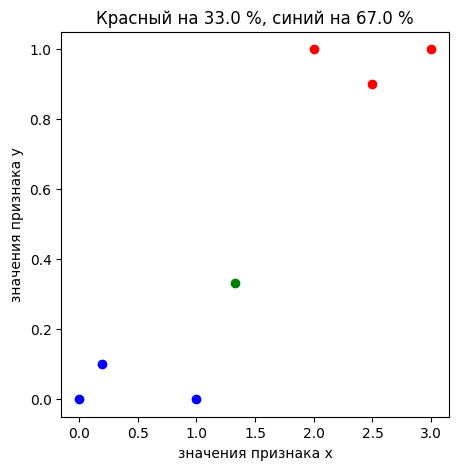

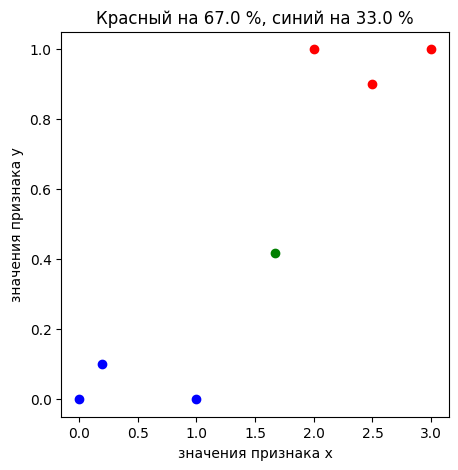

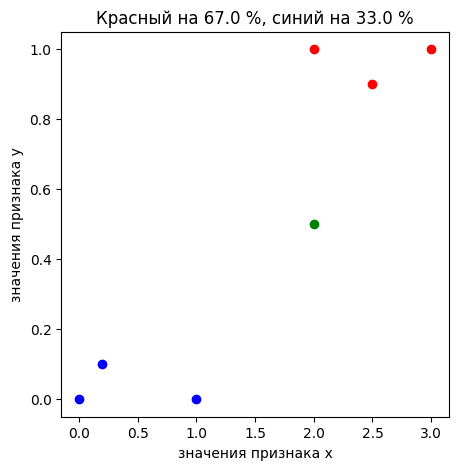

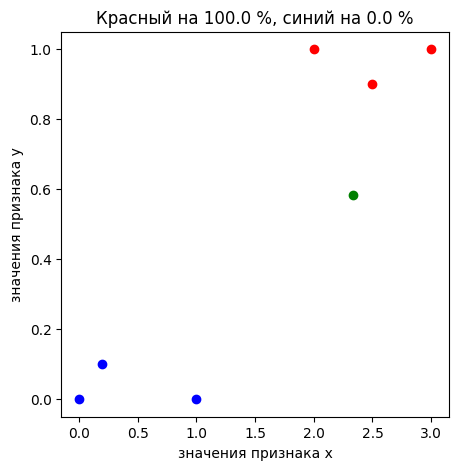

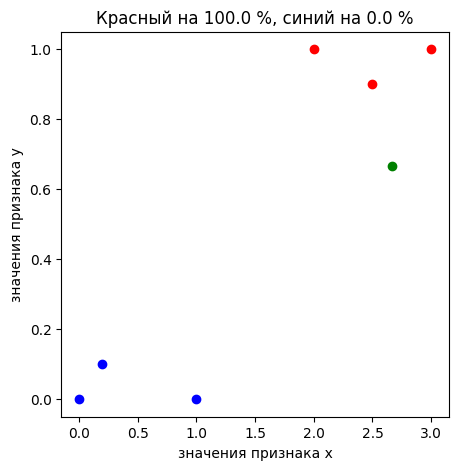

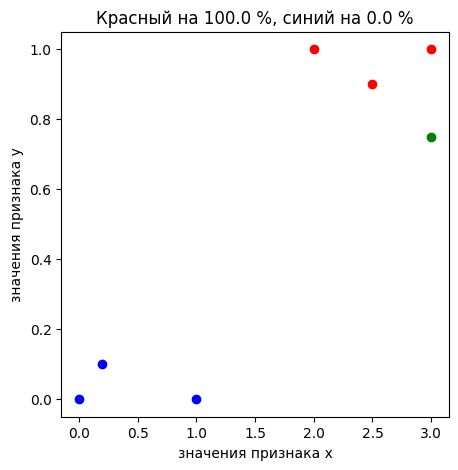

In [12]:
def show_results():
    for item in np.linspace(0, 3, 10):
        x = item
        y = item*0.25
        
        plt.figure(figsize=(5,5))
        red = data[data.target == 1]
        blue = data[data.target == 0]
        #вероятность принадлежности к красным в проц
        reb_prob = round(knn.predict_proba([[x, y]])[0][1], 2) * 100
        #вероятность принадлежности к синим в проц
        blue_prob = round(knn.predict_proba([[x, y]])[0][0], 2) * 100
        
        plt.title(f'Красный на {reb_prob} %, синий на {blue_prob} %')
        plt.xlabel('значения признака х')
        plt.ylabel('значения признака y')
        
        plt.scatter(red.x.values, red.y.values, c='r')
        plt.scatter(blue.x.values, blue.y.values, c='b')
        plt.scatter(x, y, c='g')
        plt.grid
        plt.show()
        
show_results()

Как можно видеть, когда зеленая точка «улетает» из кластера синих точек, вероятность падает, при этом вероятность принадлежности к классу в данном случае может принимать всего четыре значения (0, 0.33, 0.66, 1) в зависимости от количества соседей, так как не учтено расстояние при подсчёте вероятности.

Попробуем учесть расстояние. Для этого в модель подадим параметр weights='distance'.

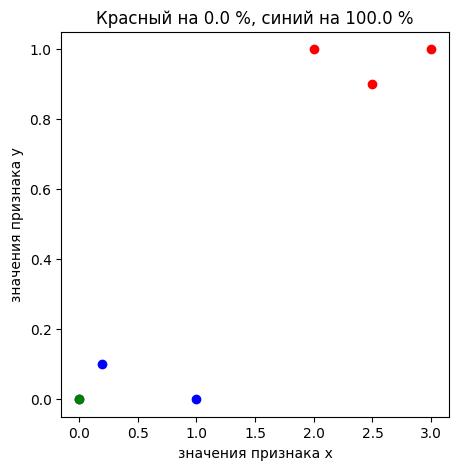

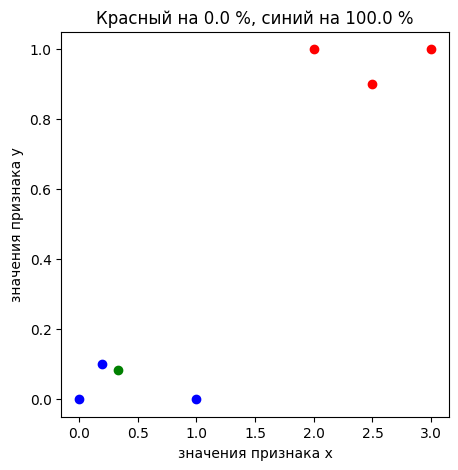

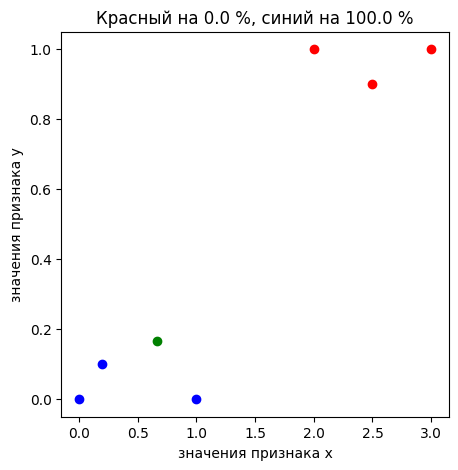

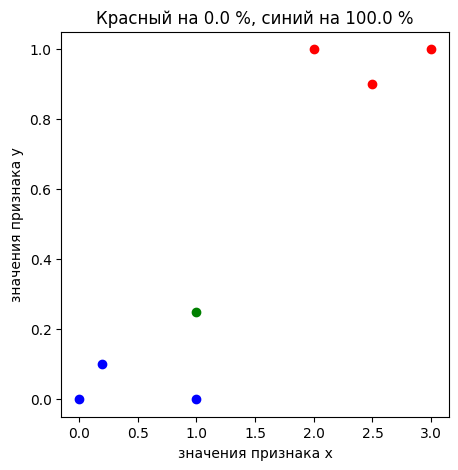

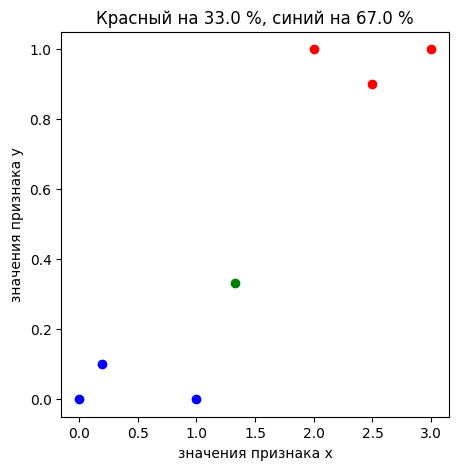

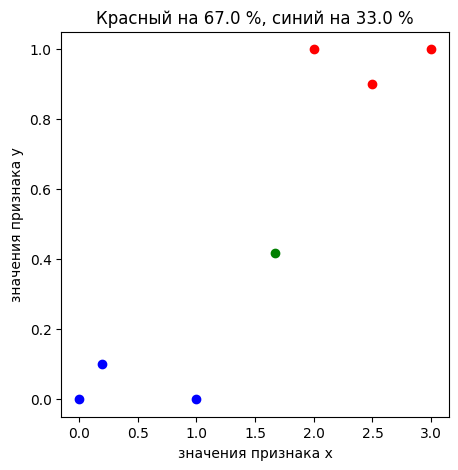

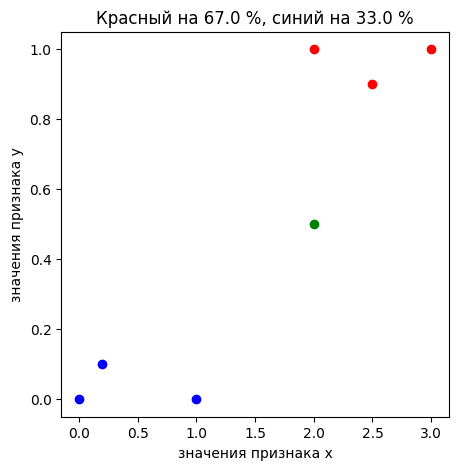

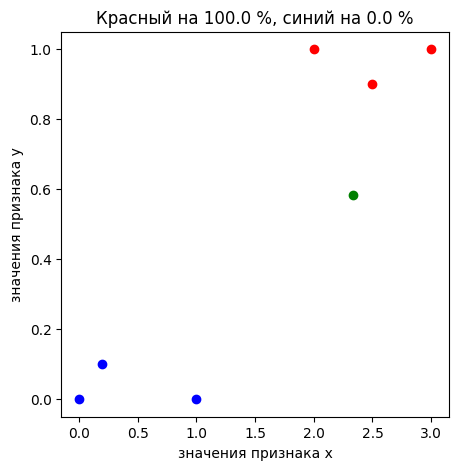

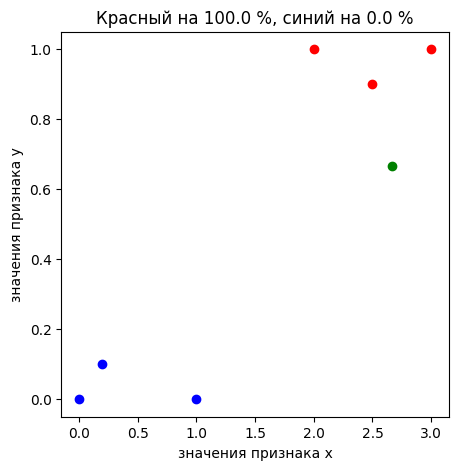

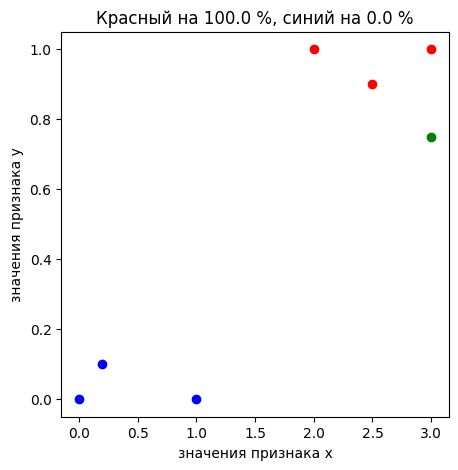

In [13]:
knn_1 = KNeighborsClassifier(
    n_neighbors=3, 
    weights='distance'
)
knn_1.fit(X, y)

show_results()

Как видим, теперь вероятности могут принимать абсолютно любые значения и точнее предсказывать вероятность принадлежности к классу.

Примечание. В случае задачи регрессии целевая метка нашего объекта определяется как среднее значение целевой метки по k ближайшим соседям.

Расчёты ведутся точно так же, только вместо вероятности предсказания класса высчитывается среднее по ближайшим соседям. Также при использовании взвешенного подхода, среднее уже будет взвешенным в зависимости от расстояния до соседа: чем ближе к точке, тем больший вклад соседа.

Предположим, целевая метка у трёх ближайших соседей в нашем случае равна 0.2, 0.3 и 0.8 соответственно, целевая метка без учёта расстояния равна (0.2+0.3+0.8)/3 = 0.43. 

# Снижение размерности

Снижение размерности также является основной задачей Metric Learning. Её суть заключается в снижении размерности признакового пространства с сохранением информативности для дальнейшей работы с уменьшенным признаковым пространством в различных задачах, например задачах классификации или кластеризации.

Тем самым, мы можем найти некоторое пространство, в котором мы можем достаточно точно разделить наши объекты по кластерам/классам или вовсе найти такое представление данных, в которых наша задача будет решаться тривиальным образом. Чаще всего это требуется для задач, в которых **ограничены ресурсы**, например для вычисления моделей на мобильных устройствах, а также для большей интерпретируемости результатов модели.

---

Тем самым мы, претерпевая небольшие потери в качестве моделей и данных, получаем гораздо менее ресурсоемкие результаты, которые можно далее визуализировать.

Основным методом снижения размерности в задачах кластеризации является **PCA (principal component analysis, метод главных компонент)**.